In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

from pass_at_k import BetaBinomialPassAtK
from reasoning_covariate import compute_covariate

with open('r1_reasoning.pkl', 'rb') as f:
    data_dict = pickle.load(f)
with open('r1_reasoning_embeddings.pkl', 'rb') as f:
    embed_payload = pickle.load(f)

embeddings_by_cfg = embed_payload['embeddings']
print(f"Embeddings: {embed_payload['model_name']}, dim={embed_payload['embed_dim']}")

SAMPLES_PER_PROMPT = 128
budget_per_problem = 10
MVUE_SAMPLES = SAMPLES_PER_PROMPT - budget_per_problem
k_values = np.arange(1, MVUE_SAMPLES + 1)

cfg_names = list(data_dict.keys())
n_cfg = len(cfg_names)

results = {}
for cfg in cfg_names:
    oracle_data = data_dict[cfg]['data']
    X = embeddings_by_cfg[cfg]
    if oracle_data.shape[0] != X.shape[0]:
        raise ValueError(f'{cfg}: data {oracle_data.shape[0]} vs embeddings {X.shape[0]}')
    if oracle_data.shape[1] != SAMPLES_PER_PROMPT:
        raise ValueError(f'{cfg}: expected {SAMPLES_PER_PROMPT} samples, got {oracle_data.shape[1]}')
    fit = compute_covariate(oracle_data, X, k_values, budget_per_problem)

    successes_oracle = np.sum(oracle_data, axis=1)
    attempts_oracle = np.full(oracle_data.shape[0], oracle_data.shape[1], dtype=np.int64)
    est_oracle = BetaBinomialPassAtK(verbose=False).fit(successes_oracle, attempts_oracle)
    results[cfg] = {
        'fit': fit,
        'alpha': est_oracle.alpha_,
        'beta': est_oracle.beta_,
        'p_hat': successes_oracle / attempts_oracle.astype(float),
        'p_hat_pos': (successes_oracle / attempts_oracle.astype(float))[(successes_oracle / attempts_oracle.astype(float)) > 0],
        'n_samples': oracle_data.shape[1],
    }


/media/dkp45/ssd/miniconda3/envs/compute/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embeddings: sentence-transformers/all-MiniLM-L6-v2, dim=384


/media/dkp45/ssd/miniconda3/envs/compute/lib/python3.12/site-packages/torch/autograd/graph.py:825: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


### Covariate-augmented reasoning comparison

Same protocol as `compare_reasoning.ipynb` (budget for fit, holdout for MVUE), with prompt embeddings from `sentence-transformers/all-MiniLM-L6-v2` cached via `embed_reasoning.py`.

**New estimators:** `cov_success_prob` (MLP on embeddings → per-problem success rate), `cov_beta_bb` (MLP → per-problem Beta prior + Beta–Binomial posterior pass@k).


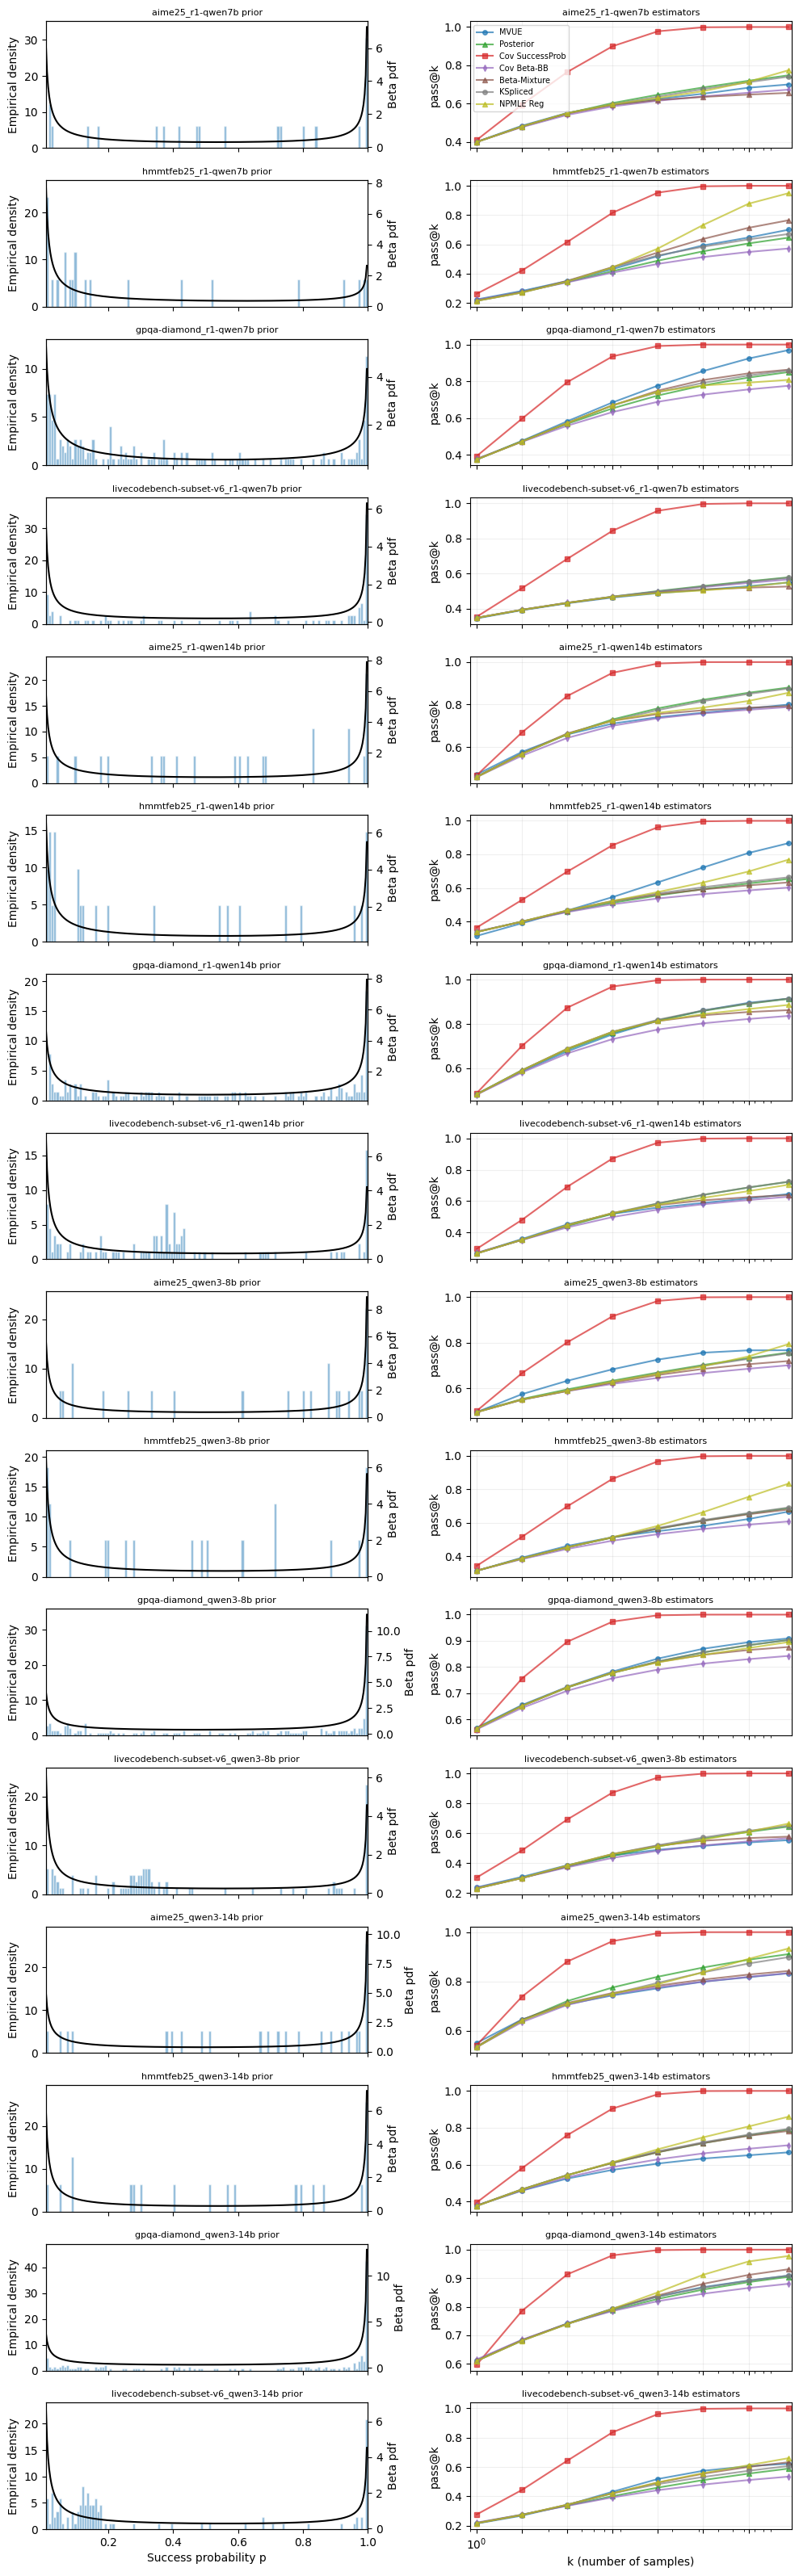

In [3]:
fig, axes = plt.subplots(n_cfg, 2, figsize=(10, max(6, 2.0 * n_cfg)), sharex='col')
if n_cfg == 1:
    axes = np.array([axes])

def _xticks_powers_of_two(k_lo, k_hi):
    k_lo = int(np.ceil(float(k_lo)))
    k_hi = int(np.floor(float(k_hi)))
    ticks = []
    p = 1
    while p <= k_hi:
        if p >= k_lo:
            ticks.append(p)
        p <<= 1
    return ticks

def _mask_k_powers_of_two(k):
    k = np.asarray(k, dtype=int)
    if k.size == 0:
        return k.astype(bool)
    pow2 = (k >= 1) & ((k & (k - 1)) == 0)
    endpoints = (k == k.min()) | (k == k.max())
    return pow2 | endpoints

PASSK_PLOT_POW2_K_ONLY = True
p_edges = np.arange(0, SAMPLES_PER_PROMPT + 1) / SAMPLES_PER_PROMPT
p_plot = np.linspace(1 / SAMPLES_PER_PROMPT, 1.0, 300)

for row, cfg in enumerate(cfg_names):
    res = results[cfg]
    fit = res['fit']
    k_plot = np.asarray(fit['k_values'])
    p_hat_pos = res['p_hat_pos']

    ax_prior = axes[row, 0]
    ax_est = axes[row, 1]

    ax_prior.hist(p_hat_pos, bins=p_edges, density=True, alpha=0.5, color='C0', edgecolor='white')
    ax_pdf = ax_prior.twinx()
    ax_pdf.plot(p_plot, beta_dist.pdf(p_plot, res['alpha'], res['beta']), 'k-', linewidth=1.5)
    ax_prior.set_xlim(1 / SAMPLES_PER_PROMPT, 1)
    ymax = ax_prior.get_ylim()[1]
    ax_prior.set_ylim(0, ymax * 1.1)
    if row == n_cfg - 1:
        ax_prior.set_xlabel('Success probability p')
    ax_prior.set_ylabel('Empirical density')
    ax_pdf.set_ylabel('Beta pdf')
    ax_prior.set_title(f'{cfg} prior', fontsize=8)

    estimator_specs = [
        ('mvue', 'MVUE', 'o-', 'C0'),
        ('estimate_posterior', 'Posterior', '^-', 'C2'),
        ('cov_success_prob', 'Cov SuccessProb', 's-', 'C3'),
        ('cov_beta_bb', 'Cov Beta-BB', 'd-', 'C4'),
        ('beta_mixture', 'Beta-Mixture', '^-', 'C5'),
        ('kspliced', 'KSpliced', 'o-', 'C7'),
        ('npmle_reg', 'NPMLE Reg', '^-', 'C8'),
        # ('beta_smoothed', 'Beta Smoothed', '^-', 'C9'),
        # ('beta_xfit', 'Beta Xfit', '^-', 'C10'),
    ]

    for key, label, style, color in estimator_specs:
        if key not in fit:
            continue
        y_series = np.asarray(fit[key], dtype=float)
        if PASSK_PLOT_POW2_K_ONLY:
            m_k = _mask_k_powers_of_two(k_plot)
            ax_est.set_xscale('log')
            ax_est.plot(k_plot[m_k], y_series[m_k], style, color=color, linewidth=1.5, markersize=4, label=label, alpha=0.7)
        else:
            ax_est.plot(k_plot, y_series, style, color=color, linewidth=1.5, markersize=4, label=label, alpha=0.5)

    ax_est.set_xlim(k_plot.min() * 0.9, k_plot.max() * 1.05)
    ax_est.set_xticks(_xticks_powers_of_two(k_plot.min(), k_plot.max()))
    if row == n_cfg - 1:
        ax_est.set_xlabel('k (number of samples)')
    ax_est.set_ylabel('pass@k')
    ax_est.grid(True, alpha=0.2)
    ax_est.set_title(f'{cfg} estimators', fontsize=8)

handles, labels = axes[0, 1].get_legend_handles_labels()
axes[0, 1].legend(handles, labels, fontsize=7, loc='upper left')
plt.tight_layout()
plt.savefig('reasoning_covariate_estimators.png', dpi=300)
plt.show()


In [4]:
import pandas as pd

estimator_errors = {}
for cfg in cfg_names:
    fit = results[cfg]['fit']
    mvue_curve = np.asarray(fit['mvue'], dtype=float)
    for est_name, est_curve in fit.items():
        if est_name in ('mvue', 'mvue_var', 'k_values'):
            continue
        est_curve = np.asarray(est_curve, dtype=float)
        wmse = np.mean((est_curve - mvue_curve) ** 2)
        wrmse = float(np.sqrt(wmse))
        estimator_errors.setdefault(est_name, {})[cfg] = wrmse

rows = []
for est_name, per_cfg in estimator_errors.items():
    vals = list(per_cfg.values())
    rows.append({
        'estimator': est_name,
        'mean_wrmse': np.mean(vals),
        'std_wrmse': np.std(vals),
        **{f'wrmse_{c}': per_cfg[c] for c in per_cfg},
    })
summary = pd.DataFrame(rows).sort_values('mean_wrmse')
summary


,estimator,mean_wrmse,std_wrmse,wrmse_aime25_r1-qwen7b,wrmse_hmmtfeb25_r1-qwen7b,wrmse_gpqa-diamond_r1-qwen7b,wrmse_livecodebench-subset-v6_r1-qwen7b,wrmse_aime25_r1-qwen14b,wrmse_hmmtfeb25_r1-qwen14b,wrmse_gpqa-diamond_r1-qwen14b,wrmse_livecodebench-subset-v6_r1-qwen14b,wrmse_aime25_qwen3-8b,wrmse_hmmtfeb25_qwen3-8b,wrmse_gpqa-diamond_qwen3-8b,wrmse_livecodebench-subset-v6_qwen3-8b,wrmse_aime25_qwen3-14b,wrmse_hmmtfeb25_qwen3-14b,wrmse_gpqa-diamond_qwen3-14b,wrmse_livecodebench-subset-v6_qwen3-14b
5,beta_mixture,0.003660,0.007554,0.001066,0.003230,0.005699,0.000139,0.000066,0.031294,0.001417,0.000102,0.003589,0.000543,0.000723,0.000760,0.000101,0.009359,0.000301,0.000162
3,kspliced,0.003936,0.006039,0.000773,0.000252,0.007109,0.000495,0.003862,0.024419,0.000014,0.003958,0.001741,0.000895,0.000105,0.005184,0.002552,0.010722,0.000001,0.000894
2,estimate_posterior,0.004484,0.006618,0.001238,0.001665,0.009053,0.000615,0.004550,0.027502,0.000013,0.003864,0.001481,0.000699,0.000111,0.004288,0.004297,0.009931,0.000038,0.002402
1,cov_beta_bb,0.006262,0.010895,0.000528,0.008948,0.023892,0.000258,0.000064,0.041796,0.004354,0.000162,0.005972,0.001341,0.003520,0.000081,0.000007,0.001065,0.000582,0.007626
4,npmle_reg,0.007514,0.010406,0.001445,0.040106,0.014195,0.000012,0.001324,0.009147,0.000582,0.001867,0.001542,0.014671,0.000369,0.005078,0.004844,0.021367,0.003286,0.000387
0,cov_success_prob,0.090657,0.066225,0.100351,0.127994,0.014910,0.210170,0.048481,0.048994,0.016061,0.142156,0.054961,0.138648,0.014621,0.206943,0.035108,0.119548,0.014777,0.156784
